## 🟢 1. IMPORT & LOAD DATA

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load datasets
df_ns = pd.read_csv("ghg_sector_ns_clean2.csv")
df_province = pd.read_csv("ghg_province_clean2.csv")

## 🟢 2. DATA OVERVIEW

### The datasets were inspected to confirm structure, data types, and completeness before analysis.

In [6]:
df_ns.head()

,Year,Sectors,Emissions
0,2013,Accommodation and food services,59
1,2013,Administrative and support services,34
2,2013,"Advertising, promotion, meals, entertainment, ...",0
3,2013,"Advertising, public relations and related serv...",1
4,2013,Aerospace product and parts manufacturing,8


In [7]:
df_ns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Year       1218 non-null   int64 
 1   Sectors    1218 non-null   object
 2   Emissions  1218 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 28.7+ KB


In [8]:
df_province.head()

,Year,Provinces,Emissions,Sectors
0,2013,Newfoundland and Labrador,114.0,Crop and animal production
1,2014,Newfoundland and Labrador,111.0,Crop and animal production (except cannabis)
2,2015,Newfoundland and Labrador,102.0,Crop and animal production (except cannabis)
3,2016,Newfoundland and Labrador,103.0,Crop and animal production (except cannabis)
4,2017,Newfoundland and Labrador,95.0,Crop and animal production (except cannabis)


In [9]:
df_province.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14225 entries, 0 to 14224
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Year       14225 non-null  int64  
 1   Provinces  14225 non-null  object 
 2   Emissions  14225 non-null  float64
 3   Sectors    14225 non-null  object 
dtypes: float64(1), int64(1), object(2)
memory usage: 444.7+ KB


## 🟢 3. DATA CLEANING (Ensure consistency)

In [10]:
df_province["Sectors"] = df_province["Sectors"].str.replace(r"\[.*\]", "", regex=True).str.strip()

## 🟢 4. EDA OBJECTIVES

### EDA Objectives:

**Analyze GHG emission trends in Nova Scotia**

**Identify top contributing sectors**

**Compare Nova Scotia emissions with national/provincial trends**

**Identify provinces with the largest emission changes**

## 🟢 5. NOVA SCOTIA ANALYSIS

### 📈 5.1 Emissions Trend

*Insight:*

**Nova Scotia emissions show a declining/increasing trend over time, with fluctuations indicating variability across years. However, the trend looked promising checking from 2019** 

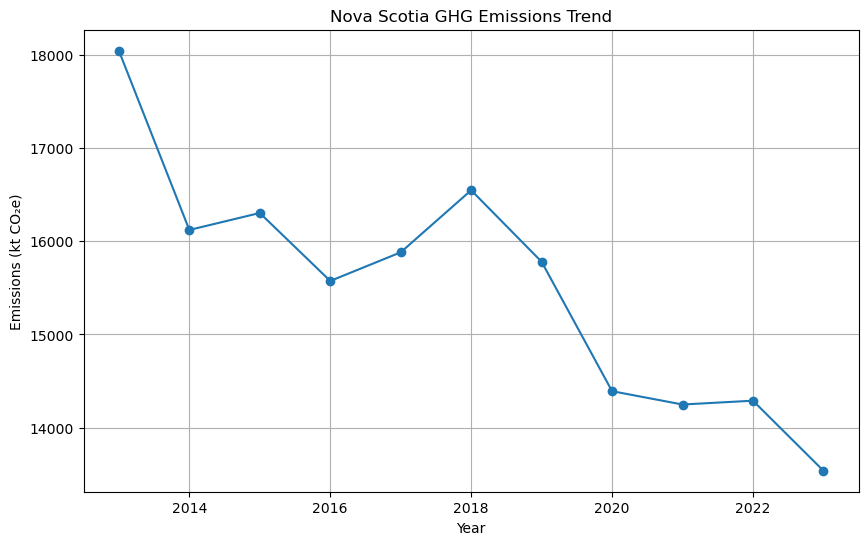

In [20]:
ns_yearly = df_ns.groupby("Year")["Emissions"].sum()

plt.figure(figsize=(10,6))
plt.plot(ns_yearly.index, ns_yearly.values, marker='o')

plt.title("Nova Scotia GHG Emissions Trend")
plt.xlabel("Year")
plt.ylabel("Emissions (kt CO₂e)")
plt.grid(True)
plt.show()

### 📊 5.2 KPI (Change %)

*Insight:*

**Emissions changed by -24.96%, indicating overall reduction of about 25% within the period under analysis.**

In [12]:
old = ns_yearly.iloc[0]
new = ns_yearly.iloc[-1]

change_pct = (new - old) / old * 100
print(f"NS GHG Change %: {change_pct:.2f}%")

NS GHG Change %: -24.96%


### 🏭 5.3 Sector Analysis (Top 10)

*Insight:*

**Emissions are concentrated in a few sectors, with Sector 1, Sector 2 and Sector 3 being dominant contributors.**


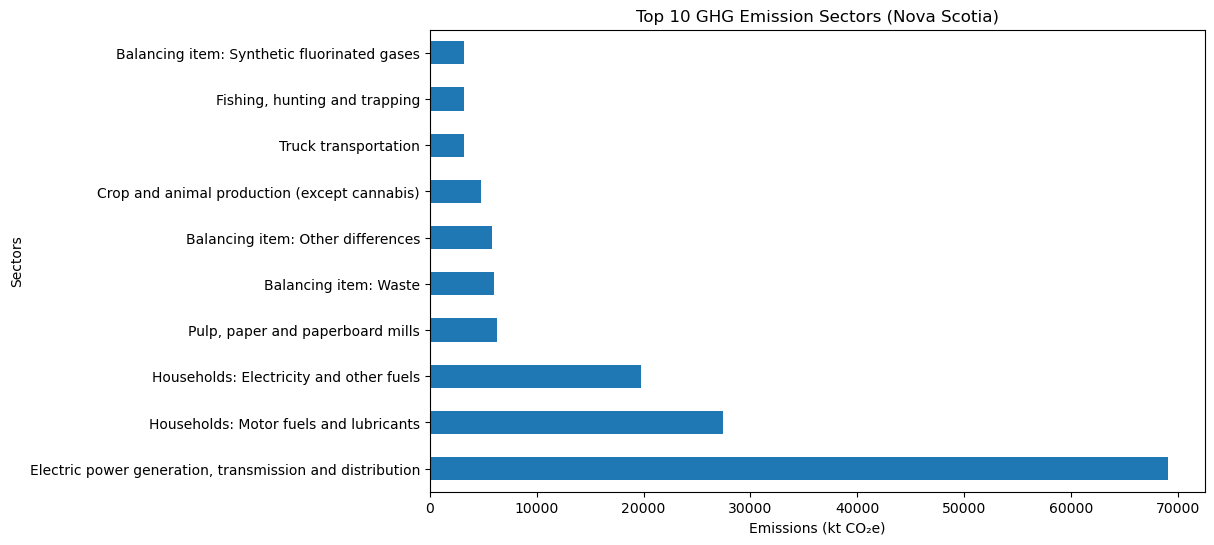

In [13]:
sector_totals = df_ns.groupby("Sectors")["Emissions"].sum().sort_values(ascending=False)

top10 = sector_totals.head(10)

plt.figure(figsize=(10,6))
top10.plot(kind='barh')

plt.title("Top 10 GHG Emission Sectors (Nova Scotia)")
plt.xlabel("Emissions (kt CO₂e)")
plt.show()

## 🟢 6. PROVINCE-LEVEL ANALYSIS (CANADA)

### 🌍 6.1 Emissions Trend by Province

In [21]:
prov_year = df_province.groupby(["Year","Provinces"])["Emissions"].sum().reset_index()

### 📈 6.2 Compare NS vs Canada

*Insight:*

**Nova Scotia contributes a smaller share of total emissions compared to national levels but follows a similar trend pattern with fluctuations indicating variability across years.**

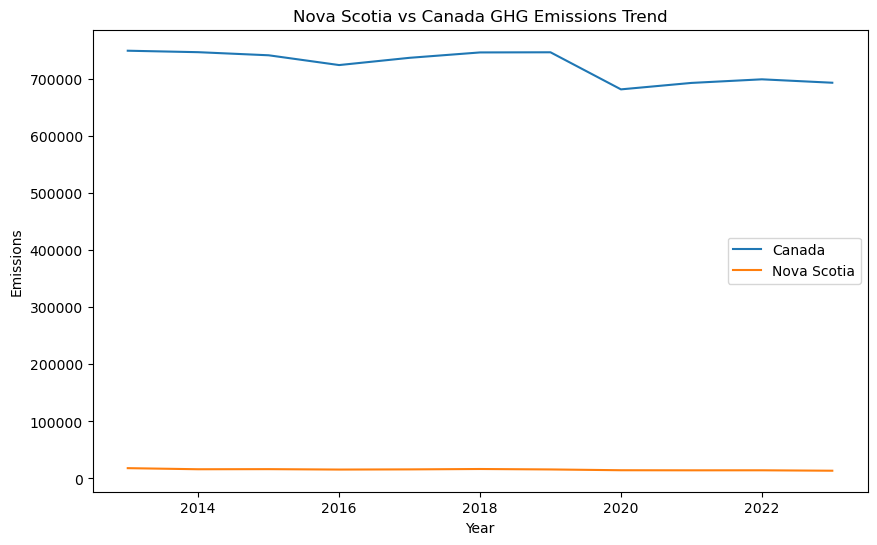

In [22]:
# Canada total
canada = df_province.groupby("Year")["Emissions"].sum()

# NS from province dataset
ns_from_prov = df_province[df_province["Provinces"] == "Nova Scotia"] \
                .groupby("Year")["Emissions"].sum()

plt.figure(figsize=(10,6))
plt.plot(canada.index, canada.values, label="Canada")
plt.plot(ns_from_prov.index, ns_from_prov.values, label="Nova Scotia")

plt.legend()
plt.title("Nova Scotia vs Canada GHG Emissions Trend")
plt.xlabel("Year")
plt.ylabel("Emissions")
plt.show()

### 📊 6.3 Province Change Ranking

*Insight:*

**Provinces such as Yukon show the highest increase, while Nova Scotia show the largest decrease.**

In [16]:
prov_change = df_province.groupby(["Provinces","Year"])["Emissions"].sum().unstack()

change = ((prov_change.iloc[:,-1] - prov_change.iloc[:,0]) / prov_change.iloc[:,0]) * 100

change.sort_values(ascending=False)

Provinces
Yukon                        11.892797
Nunavut                       3.493450
Manitoba                      0.178933
Quebec                        0.138292
British Columbia             -0.736055
Prince Edward Island         -3.221884
Ontario                      -5.552250
Alberta                      -9.638075
Saskatchewan                -11.158391
Northwest Territories       -13.878327
New Brunswick               -18.319088
Newfoundland and Labrador   -19.152629
Nova Scotia                 -24.962589
dtype: float64

## 🟢 7. SIMPLE PREDICTIVE MODEL


### 📈 Plot Forecast

*Insight:*

**The model predicts that emissions will decrease, assuming current trends continue.**

In [35]:
# Prepare data for predictive model

from sklearn.linear_model import LinearRegression
import numpy as np
ns_yearly = df_ns.groupby("Year")["Emissions"].sum().reset_index()

X = ns_yearly[["Year"]]
y = ns_yearly["Emissions"]

# Train model
model = LinearRegression()
model.fit(X, y)

# Create future years
last_year = ns_yearly["Year"].max()

future_years = pd.DataFrame({
    "Year": range(last_year + 1, last_year + 6)
})

# Predict
predictions = model.predict(future_years)

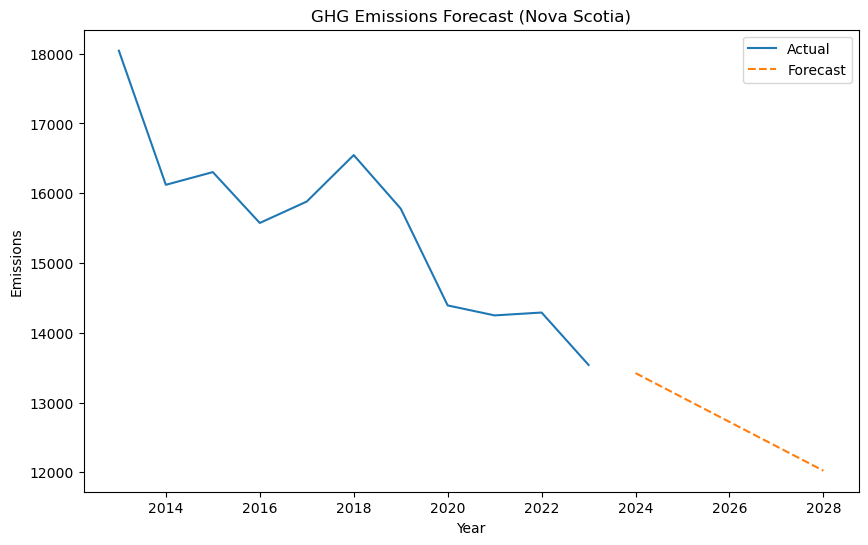

In [36]:
ns_yearly = df_ns.groupby("Year")["Emissions"].sum().reset_index()

plt.figure(figsize=(10,6))

plt.plot(ns_yearly["Year"], ns_yearly["Emissions"], label="Actual")

plt.plot(future_years["Year"], predictions, linestyle='--', label="Forecast")

plt.legend()
plt.title("GHG Emissions Forecast (Nova Scotia)")
plt.xlabel("Year")
plt.ylabel("Emissions")

plt.show()

In [39]:
# A quick Glance for the Predicted Emissions as shown in the graph above

print(future_years, predictions)

   Year
0  2024
1  2025
2  2026
3  2027
4  2028 [13421.49090909 13071.75454545 12722.01818182 12372.28181818
 12022.54545455]


In [42]:
# Table format for the Predicted Emissions as shown in the graph above

forecast_df = future_years.copy()
forecast_df["Predicted_Emissions"] = predictions

forecast_df

,Year,Predicted_Emissions
0,2024,13421.490909
1,2025,13071.754545
2,2026,12722.018182
3,2027,12372.281818
4,2028,12022.545455


In [52]:
# A quick Glance for Emissions on NS Dataset for comparison with Predicted Emission above.

ns_yearly = df_ns.groupby("Year")["Emissions"].sum().reset_index()
ns_yearly

,Year,Emissions
0,2013,18043
1,2014,16121
2,2015,16303
3,2016,15574
4,2017,15881
5,2018,16547
6,2019,15780
7,2020,14392
8,2021,14249
9,2022,14290


## 🟢 8. ASSUMPTIONS

**The model assumes a linear trend in emissions over time**

**External factors such as policy or economic shifts are not included**

**Forecast accuracy is limited due to simplicity of the model**

🟢 9. EXPORT FOR POWER BI

In [43]:
ns_yearly.to_csv("PwrBI_ns_yearly_trend.csv", index=False)
top10.to_csv("PwrBI_ns_sector_top10.csv")

CHECKLIST

✔ NS trend
✔ NS KPI
✔ NS sector analysis
✔ Province comparison
✔ Province ranking
✔ Forecast
✔ Insights written
✔ Assumptions written